<a href="https://colab.research.google.com/github/Kitossan22/HDAC11-SAR-Analysis/blob/main/HDAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# HDAC11 Inhibitor SAR Analysis
## Bis-aryl sulfate (Series D) vs Sulfamate (EVB) series

# This notebook presents a structure-activity relationship (SAR) analysis of two
# HDAC11 inhibitor series using RDKit and pandas:

# - **Series D**: Bis-aryl sulfate scaffold (12 compounds) — from Christian A. Olsen, *JACS Au* 2024
# - **EVB series**: Sulfamate scaffold (5 tested compounds) — from Balatsos, MSc Thesis, KU 2025

# **Key question:** Do the same physicochemical trends drive potency across both scaffolds?

# Author: Marcos San Segundo Eizaguirre | Postdoctoral Researcher, University of Copenhagen

In [5]:
!pip install rdkit seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 27.6 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem.Draw import MolsToGridImage
from IPython.display import display
import seaborn as sns

In [7]:
## 1. Series D — Bis-aryl Sulfate Scaffold
# Source: Christian A. Olsen, *JACS Au* 2024, DOI: 10.1021/jacsau.4c00042

# 12 compounds with HDAC11 Ki values (nM). Scaffold: aryl sulfate ZBG with hydroxamate cap.

In [8]:
smiles_D = [
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccccc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(Br)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(C(F)(F)F)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2cccc(-c3ccccc3)c2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2cccc(C(C)C)c2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(C(C)C)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2cccc(C(C)(C)C)c2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(C(C)(C)C)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(C(C)(C)C)cc2C)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(Oc3ccccc3)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc(-n3ccnc3)cc2)c1C",
    "O=C(NO)c1cccc(OS(=O)(=O)Oc2ccc3ccccc3c2)c1C",
]
ids_D = ["D1","D2","D3","D4","D8","D9","D11","D12","D19","D21","D23","D24"]
hdac11_ki_D = {
    "D1":  2495, "D2":  457, "D3":  187, "D4":  272,
    "D8":   714, "D9":  178, "D11": 646, "D12": 581,
    "D19":  542, "D21": 149, "D23":1032, "D24": 458,
}

df_D = pd.DataFrame({"ID": ids_D, "SMILES": smiles_D})
df_D["Mol"]      = df_D["SMILES"].apply(Chem.MolFromSmiles)
df_D             = df_D[df_D["Mol"].notna()].copy()
df_D["MW"]       = df_D["Mol"].apply(Descriptors.MolWt)
df_D["LogP"]     = df_D["Mol"].apply(Descriptors.MolLogP)
df_D["HBD"]      = df_D["Mol"].apply(Descriptors.NumHDonors)
df_D["HBA"]      = df_D["Mol"].apply(Descriptors.NumHAcceptors)
df_D["TPSA"]     = df_D["Mol"].apply(Descriptors.TPSA)
df_D["RotBonds"] = df_D["Mol"].apply(Descriptors.NumRotatableBonds)
df_D["Ki_nM"]    = df_D["ID"].map(hdac11_ki_D)

def tier_D(ki):
    if ki < 200:   return "Potent"
    elif ki < 500: return "Moderate"
    elif ki < 800: return "Weak"
    else:          return "Inactive"

color_map = {"Potent": "tomato", "Moderate": "darkorange", "Weak": "gold", "Inactive": "steelblue"}
df_D["Tier"]  = df_D["Ki_nM"].apply(tier_D)
df_D["Color"] = df_D["Tier"].map(color_map)

print(df_D[["ID","Ki_nM","Tier","MW","LogP","TPSA","RotBonds"]].to_string(index=False))

 ID  Ki_nM     Tier      MW    LogP   TPSA  RotBonds
 D1   2495 Inactive 323.326 1.81662 101.93         5
 D2    457 Moderate 402.222 2.57912 101.93         5
 D3    187   Potent 391.323 2.83542 101.93         5
 D4    272 Moderate 399.424 3.48362 101.93         6
 D8    714     Weak 365.407 2.94002 101.93         6
 D9    178   Potent 365.407 2.94002 101.93         6
D11    646     Weak 379.434 3.11412 101.93         5
D12    581     Weak 379.434 3.11412 101.93         5
D19    542     Weak 393.461 3.42254 101.93         5
D21    149   Potent 415.423 3.60892 111.16         7
D23   1032 Inactive 389.389 2.00232 119.75         6
D24    458 Moderate 373.386 2.96982 101.93         5


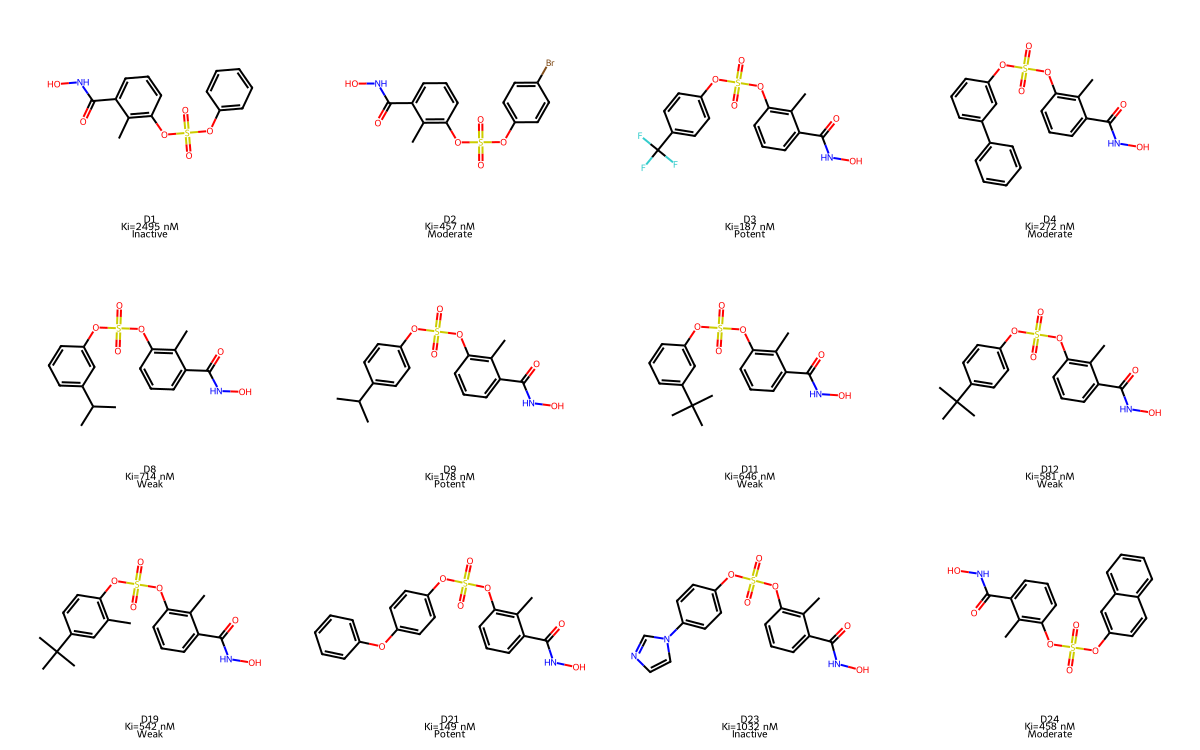

In [9]:
mols_D    = list(df_D["Mol"])
labels_D  = [f"{row['ID']}\nKi={row['Ki_nM']} nM\n{row['Tier']}"
             for _, row in df_D.iterrows()]

img = MolsToGridImage(
    mols_D,
    molsPerRow=4,
    subImgSize=(300, 250),
    legends=labels_D
)
display(img)

In [10]:
## 2. EVB Sulfamate Series
# Source: Balatsos, E. MSc Thesis, University of Copenhagen, 2025 (co-supervised with C. Olsen)

# Sulfamate ZBG with benzylamine cap group variations. 5 compounds with HDAC11 Ki values.

In [11]:
evb_data = [
    ("19", "4-CF3",        "CC3=C(C(NO)=O)C=CC=C3OS(NCC4=CC=C(C(F)(F)F)C=C4)(=O)=O",   79),
    ("20", "3-CF3",        "CC7=C(C(NO)=O)C=CC=C7OS(NCC8=CC(C(F)(F)F)=CC=C8)(=O)=O",   82),
    ("11", "2-Br",         "CC%21=C(C(NO)=O)C=CC=C%21OS(NCC%22=CC=CC=C%22Br)(=O)=O",   92),
    ("30", "N-Me (lead)",  "CC%23=C(C(NO)=O)C=CC=C%23OS(N(C)CC%24=CC=CC=C%24)(=O)=O",  68),
    ("34", "3,5-bis-CF3",  "CC%34=C(C(NO)=O)C=CC=C%34OS(NCC%35=CC(C(F)(F)F)=CC(C(F)(F)F)=C%35)(=O)=O", 93),
]

df_evb = pd.DataFrame(evb_data, columns=["ID","Cap_Group","SMILES","Ki_nM"])
df_evb["Mol"]      = df_evb["SMILES"].apply(Chem.MolFromSmiles)
df_evb             = df_evb[df_evb["Mol"].notna()].copy()
df_evb["MW"]       = df_evb["Mol"].apply(Descriptors.MolWt)
df_evb["LogP"]     = df_evb["Mol"].apply(Descriptors.MolLogP)
df_evb["HBD"]      = df_evb["Mol"].apply(Descriptors.NumHDonors)
df_evb["HBA"]      = df_evb["Mol"].apply(Descriptors.NumHAcceptors)
df_evb["TPSA"]     = df_evb["Mol"].apply(Descriptors.TPSA)
df_evb["RotBonds"] = df_evb["Mol"].apply(Descriptors.NumRotatableBonds)

def tier_evb(ki):
    if ki < 75:   return "Potent"
    elif ki < 90: return "Moderate"
    else:         return "Weak"

df_evb["Tier"]  = df_evb["Ki_nM"].apply(tier_evb)
df_evb["Color"] = df_evb["Tier"].map(color_map)

print(df_evb[["ID","Cap_Group","Ki_nM","Tier","MW","LogP","TPSA","RotBonds"]].to_string(index=False))

ID   Cap_Group  Ki_nM     Tier      MW    LogP   TPSA  RotBonds
19       4-CF3     79 Moderate 404.366 2.54622 104.73         6
20       3-CF3     82 Moderate 404.366 2.54622 104.73         6
11        2-Br     92     Weak 415.265 2.28992 104.73         6
30 N-Me (lead)     68   Potent 350.396 1.86962  95.94         6
34 3,5-bis-CF3     93     Weak 472.363 3.56502 104.73         6


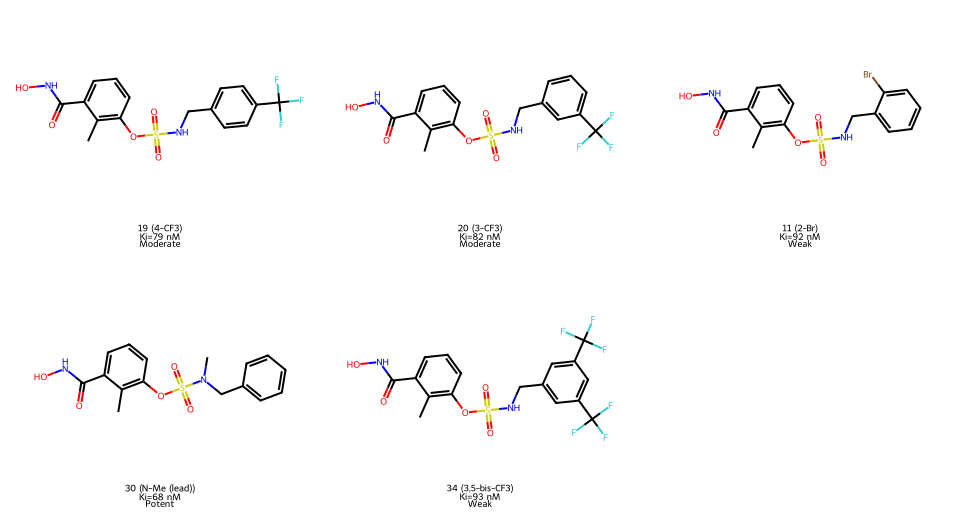

In [12]:
mols_evb   = list(df_evb["Mol"])
labels_evb = [f"{row['ID']} ({row['Cap_Group']})\nKi={row['Ki_nM']} nM\n{row['Tier']}"
              for _, row in df_evb.iterrows()]

img_evb = MolsToGridImage(
    mols_evb,
    molsPerRow=3,
    subImgSize=(320, 260),
    legends=labels_evb
)
display(img_evb)

In [13]:
## 3. SAR Analysis — Descriptor vs Activity Plots

# Comparing physicochemical descriptors (MW, LogP, TPSA, RotBonds) against HDAC11 Ki
# across both series. Circles = Series D (sulfate), Triangles = EVB (sulfamate).
# Activity thresholds shown as dashed lines.

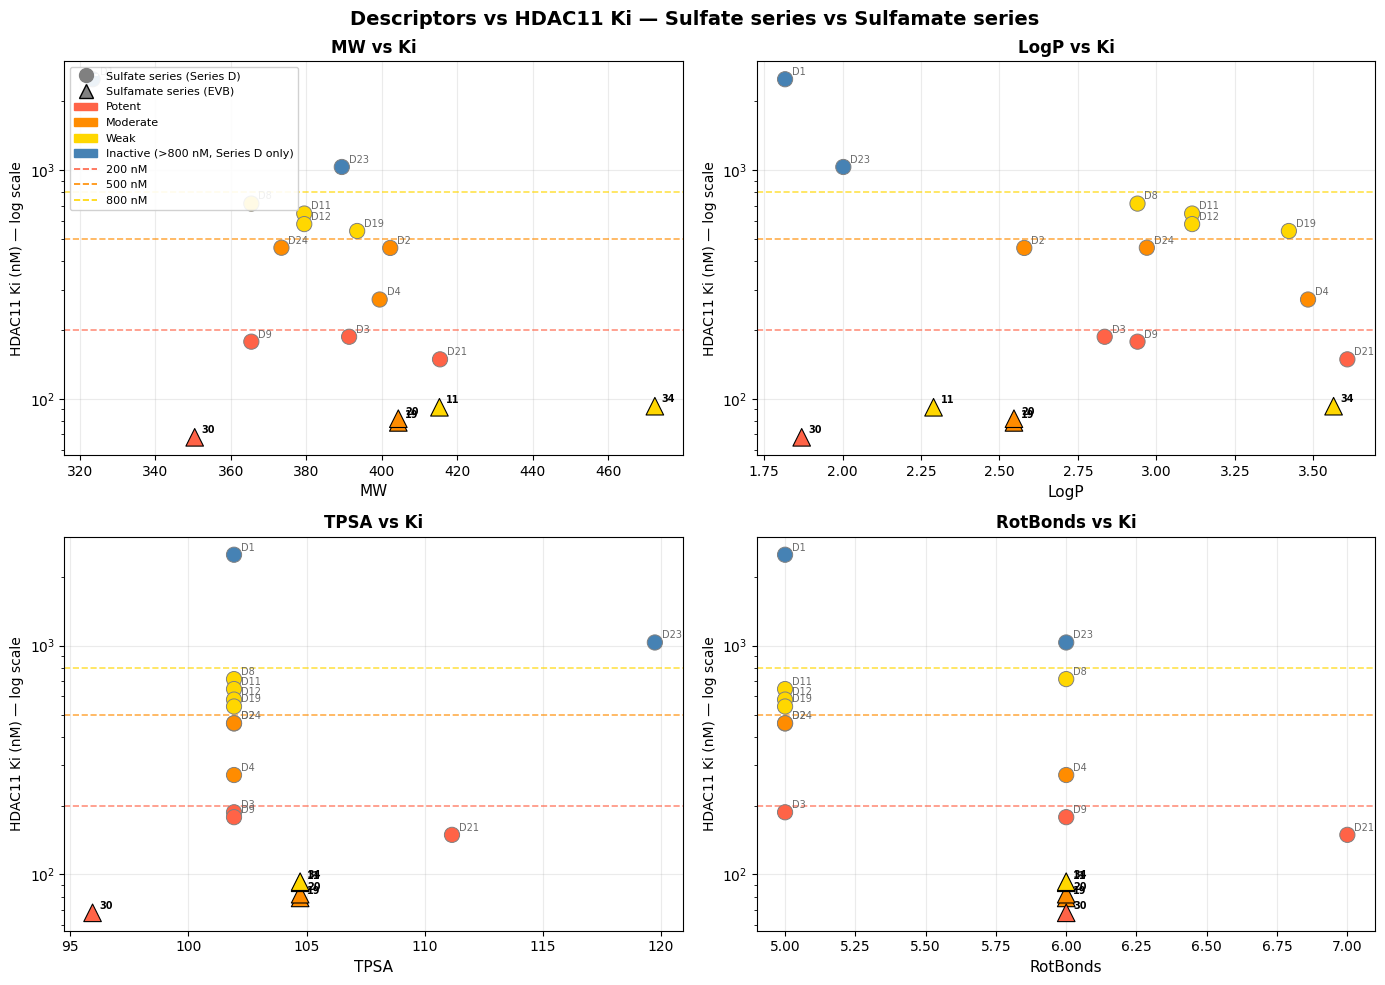

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Descriptors vs HDAC11 Ki — Sulfate series vs Sulfamate series",
             fontsize=14, fontweight="bold")

axes  = axes.flatten()
descs = ["MW", "LogP", "TPSA", "RotBonds"]

for ax, desc in zip(axes, descs):

    # Series D — circles
    ax.scatter(df_D[desc], df_D["Ki_nM"],
               c=df_D["Color"], s=120, marker="o",
               edgecolors="gray", linewidths=0.7, zorder=3)
    for _, row in df_D.iterrows():
        ax.annotate(row["ID"], (row[desc], row["Ki_nM"]),
                    fontsize=7, color="dimgray",
                    textcoords="offset points", xytext=(5, 3))

    # EVB — triangles
    ax.scatter(df_evb[desc], df_evb["Ki_nM"],
               c=df_evb["Color"], s=160, marker="^",
               edgecolors="black", linewidths=0.8, zorder=5)
    for _, row in df_evb.iterrows():
        ax.annotate(row["ID"], (row[desc], row["Ki_nM"]),
                    fontsize=7, color="black", fontweight="bold",
                    textcoords="offset points", xytext=(5, 3))

    ax.set_yscale("log")
    ax.set_xlabel(desc, fontsize=11)
    ax.set_ylabel("HDAC11 Ki (nM) — log scale", fontsize=10)
    ax.set_title(f"{desc} vs Ki", fontsize=12, fontweight="bold")
    ax.axhline(200, color="tomato",     linestyle="--", linewidth=1.2, alpha=0.7)
    ax.axhline(500, color="darkorange", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.axhline(800, color="gold",       linestyle="--", linewidth=1.2, alpha=0.7)
    ax.grid(True, alpha=0.25)

legend_elements = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="gray",
           markersize=10, markeredgecolor="gray",  label="Sulfate series (Series D)"),
    Line2D([0],[0], marker="^", color="w", markerfacecolor="gray",
           markersize=10, markeredgecolor="black", label="Sulfamate series (EVB)"),
    mpatches.Patch(color="tomato",     label="Potent"),
    mpatches.Patch(color="darkorange", label="Moderate"),
    mpatches.Patch(color="gold",       label="Weak"),
    mpatches.Patch(color="steelblue",  label="Inactive (>800 nM, Series D only)"),
    Line2D([0],[0], color="tomato",     linestyle="--", linewidth=1.2, label="200 nM"),
    Line2D([0],[0], color="darkorange", linestyle="--", linewidth=1.2, label="500 nM"),
    Line2D([0],[0], color="gold",       linestyle="--", linewidth=1.2, label="800 nM"),
]

axes[0].legend(handles=legend_elements, fontsize=8, loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.savefig("combined_2x2_descriptors_vs_ki.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# ## 4. Molecular Fingerprints & Tanimoto Similarity

# Molecular fingerprints encode each compound as a binary vector where each bit represents
# the presence (1) or absence (0) of a structural feature within a given radius.

# We use **Morgan fingerprints (ECFP4)** — radius=2, 2048 bits — the industry standard
# for SAR and similarity analysis in drug discovery.

# Tanimoto similarity (Tc) measures overlap between two fingerprint vectors:
# - Tc = 1.0 → identical structures
# - Tc > 0.85 → very similar (same scaffold)
# - Tc < 0.4 → structurally distinct

# Two heatmaps are generated:
# 1. Series D internal similarity (12×12)
# 2. Cross-series similarity: Series D vs EVB (12×5)

In [16]:
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

# New API: MorganGenerator (ECFP4: radius=2, 2048 bits)
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

df_D["FP"]   = df_D["Mol"].apply(morgan_gen.GetFingerprint)
df_evb["FP"] = df_evb["Mol"].apply(morgan_gen.GetFingerprint)

print(f"Series D fingerprints:   {len(df_D)} compounds")
print(f"EVB series fingerprints: {len(df_evb)} compounds")
print(f"Example fingerprint (D1), first 20 bits: {list(df_D['FP'].iloc[0])[:20]}")

Series D fingerprints:   12 compounds
EVB series fingerprints: 5 compounds
Example fingerprint (D1), first 20 bits: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


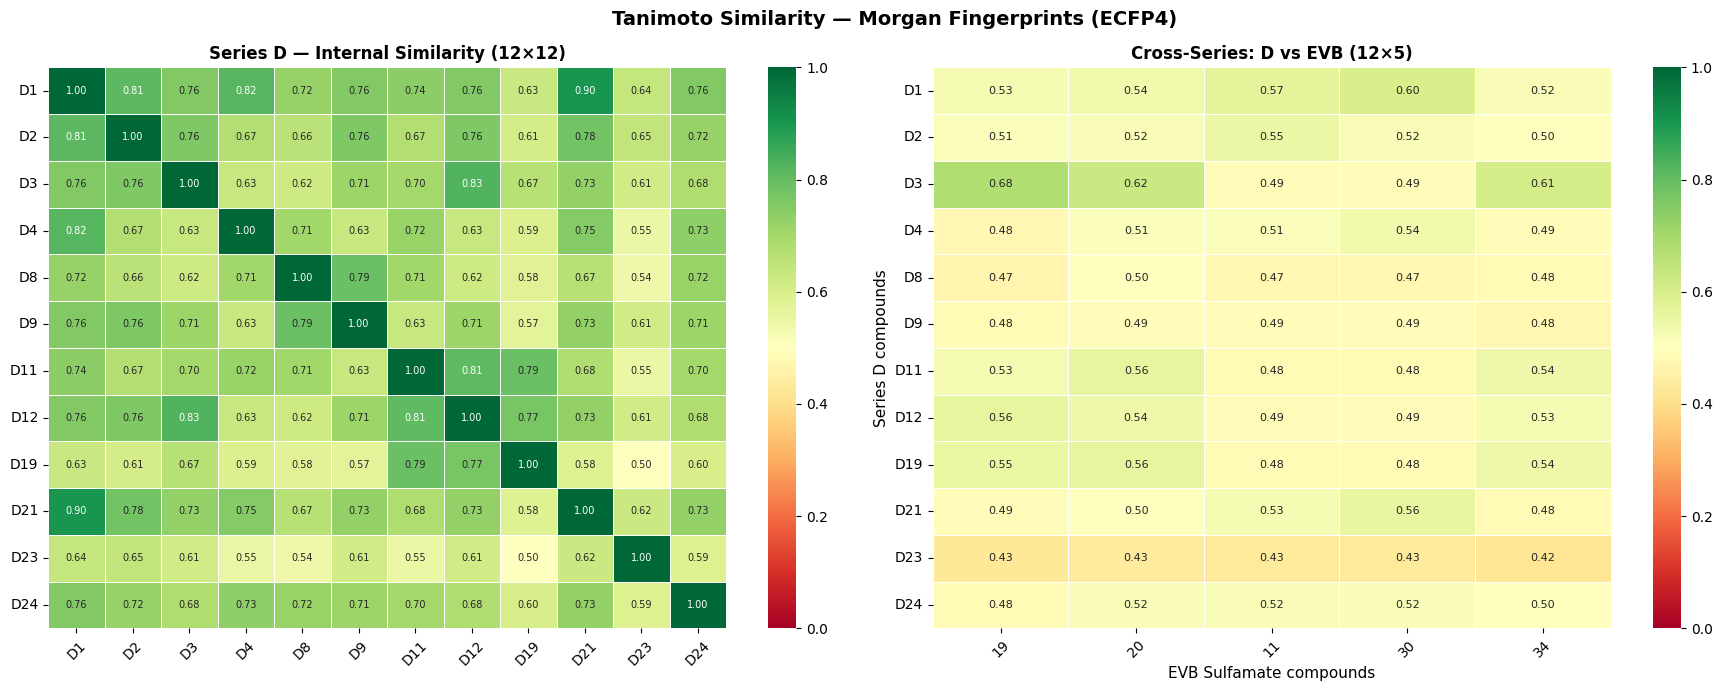

In [17]:
# ── Helper: build similarity matrix ──────────────────────────
def tanimoto_matrix(fps_a, fps_b):
    matrix = np.zeros((len(fps_a), len(fps_b)))
    for i, fp_a in enumerate(fps_a):
        for j, fp_b in enumerate(fps_b):
            matrix[i, j] = DataStructs.TanimotoSimilarity(fp_a, fp_b)
    return matrix

fps_D   = list(df_D["FP"])
fps_evb = list(df_evb["FP"])

# ── Matrix 1: Series D internal (12×12) ──────────────────────
sim_D = tanimoto_matrix(fps_D, fps_D)

# ── Matrix 2: Cross-series D vs EVB (12×5) ───────────────────
sim_cross = tanimoto_matrix(fps_D, fps_evb)

# ── Plot both heatmaps ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Tanimoto Similarity — Morgan Fingerprints (ECFP4)",
             fontsize=14, fontweight="bold")

# Heatmap 1: Series D internal
sns.heatmap(sim_D,
            ax=axes[0],
            xticklabels=df_D["ID"],
            yticklabels=df_D["ID"],
            annot=True, fmt=".2f", annot_kws={"size": 7},
            cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, linecolor="white")
axes[0].set_title("Series D — Internal Similarity (12×12)", fontsize=12, fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# Heatmap 2: Cross-series D vs EVB
sns.heatmap(sim_cross,
            ax=axes[1],
            xticklabels=df_evb["ID"],
            yticklabels=df_D["ID"],
            annot=True, fmt=".2f", annot_kws={"size": 8},
            cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, linecolor="white")
axes[1].set_title("Cross-Series: D vs EVB (12×5)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("EVB Sulfamate compounds", fontsize=11)
axes[1].set_ylabel("Series D compounds", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("tanimoto_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# ## 5. Drug-likeness & ADMET Filtering

# Beyond potency, a viable drug candidate must have acceptable pharmacokinetic properties.
# We apply three sequential filters to both series:

# 1. **Lipinski's Rule of Five (Ro5)** — oral bioavailability predictor
#    - MW ≤ 500 Da
#    - LogP ≤ 5
#    - HBD ≤ 5
#    - HBA ≤ 10

# 2. **Veber rules** — oral bioavailability (independent of Ro5)
#    - RotBonds ≤ 10
#    - TPSA ≤ 140 Ų

# 3. **PAINS filter** — flags compounds known to give false positives in biochemical assays

In [19]:
# ── Lipinski Ro5 ─────────────────────────────────────────────
def lipinski(row):
    rules = {
        "MW ≤ 500":  row["MW"]       <= 500,
        "LogP ≤ 5":  row["LogP"]     <= 5,
        "HBD ≤ 5":   row["HBD"]      <= 5,
        "HBA ≤ 10":  row["HBA"]      <= 10,
    }
    passes = sum(rules.values())
    return pd.Series({
        **rules,
        "Ro5_passes": passes,
        "Ro5_ok": passes >= 4  # all 4 rules must pass
    })

# ── Veber rules ───────────────────────────────────────────────
def veber(row):
    ok = (row["RotBonds"] <= 10) and (row["TPSA"] <= 140)
    return pd.Series({"Veber_ok": ok})

# ── Apply to both series ──────────────────────────────────────
for df in [df_D, df_evb]:
    df[["MW ≤ 500","LogP ≤ 5","HBD ≤ 5","HBA ≤ 10","Ro5_passes","Ro5_ok"]] = \
        df.apply(lipinski, axis=1)
    df[["Veber_ok"]] = df.apply(veber, axis=1)

# ── Print summary ─────────────────────────────────────────────
print("=== Series D — Lipinski + Veber ===")
print(df_D[["ID","Ki_nM","Tier","MW","LogP","HBD","HBA","TPSA","RotBonds",
            "Ro5_ok","Veber_ok"]].to_string(index=False))

print("\n=== EVB Sulfamate — Lipinski + Veber ===")
print(df_evb[["ID","Cap_Group","Ki_nM","Tier","MW","LogP","HBD","HBA","TPSA","RotBonds",
              "Ro5_ok","Veber_ok"]].to_string(index=False))

=== Series D — Lipinski + Veber ===
 ID  Ki_nM     Tier      MW    LogP  HBD  HBA   TPSA  RotBonds  Ro5_ok  Veber_ok
 D1   2495 Inactive 323.326 1.81662    2    6 101.93         5    True      True
 D2    457 Moderate 402.222 2.57912    2    6 101.93         5    True      True
 D3    187   Potent 391.323 2.83542    2    6 101.93         5    True      True
 D4    272 Moderate 399.424 3.48362    2    6 101.93         6    True      True
 D8    714     Weak 365.407 2.94002    2    6 101.93         6    True      True
 D9    178   Potent 365.407 2.94002    2    6 101.93         6    True      True
D11    646     Weak 379.434 3.11412    2    6 101.93         5    True      True
D12    581     Weak 379.434 3.11412    2    6 101.93         5    True      True
D19    542     Weak 393.461 3.42254    2    6 101.93         5    True      True
D21    149   Potent 415.423 3.60892    2    7 111.16         7    True      True
D23   1032 Inactive 389.389 2.00232    2    7 119.75         6    True   

In [20]:
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# Build PAINS filter catalog
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
catalog = FilterCatalog(params)

def pains_flag(mol):
    entry = catalog.GetFirstMatch(mol)
    if entry:
        return True, entry.GetDescription()
    return False, "Clean"

for df in [df_D, df_evb]:
    df[["PAINS_flag","PAINS_reason"]] = df["Mol"].apply(
        lambda m: pd.Series(pains_flag(m))
    )

print("=== Series D — PAINS ===")
print(df_D[["ID","Ki_nM","Tier","PAINS_flag","PAINS_reason"]].to_string(index=False))

print("\n=== EVB — PAINS ===")
print(df_evb[["ID","Cap_Group","Ki_nM","PAINS_flag","PAINS_reason"]].to_string(index=False))

=== Series D — PAINS ===
 ID  Ki_nM     Tier  PAINS_flag PAINS_reason
 D1   2495 Inactive       False        Clean
 D2    457 Moderate       False        Clean
 D3    187   Potent       False        Clean
 D4    272 Moderate       False        Clean
 D8    714     Weak       False        Clean
 D9    178   Potent       False        Clean
D11    646     Weak       False        Clean
D12    581     Weak       False        Clean
D19    542     Weak       False        Clean
D21    149   Potent       False        Clean
D23   1032 Inactive       False        Clean
D24    458 Moderate       False        Clean

=== EVB — PAINS ===
ID   Cap_Group  Ki_nM  PAINS_flag PAINS_reason
19       4-CF3     79       False        Clean
20       3-CF3     82       False        Clean
11        2-Br     92       False        Clean
30 N-Me (lead)     68       False        Clean
34 3,5-bis-CF3     93       False        Clean


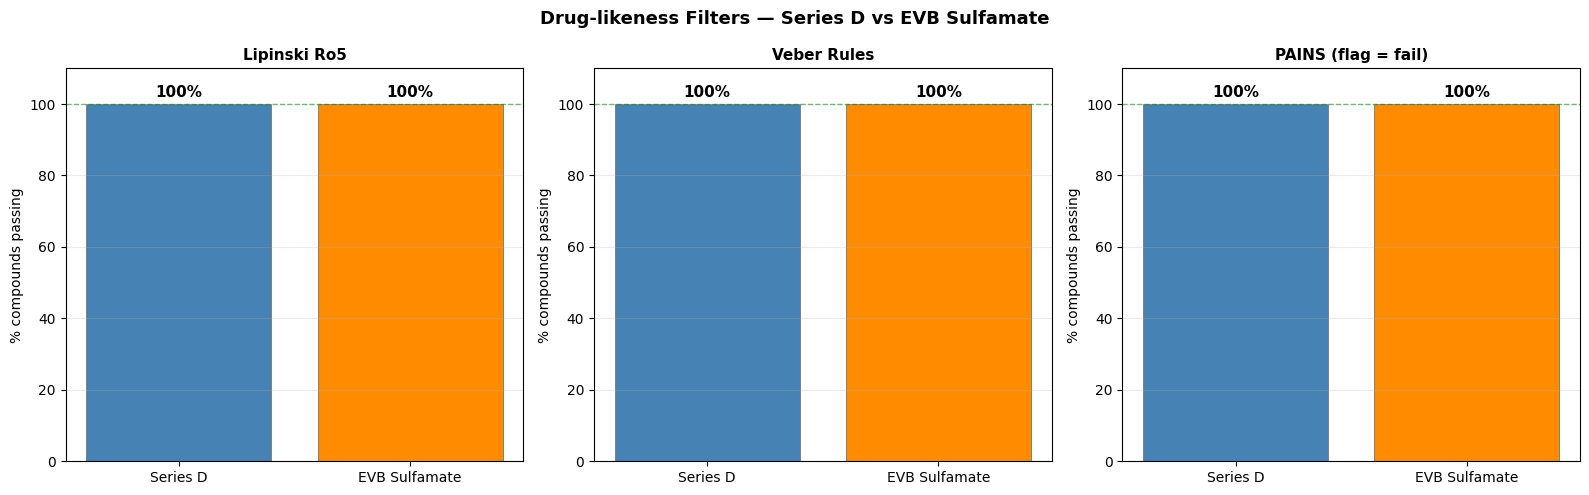

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Drug-likeness Filters — Series D vs EVB Sulfamate",
             fontsize=13, fontweight="bold")

series_labels = ["Series D", "EVB Sulfamate"]
colors        = ["steelblue", "darkorange"]

for ax, col, title in zip(axes,
                           ["Ro5_ok", "Veber_ok", "PAINS_flag"],
                           ["Lipinski Ro5", "Veber Rules", "PAINS (flag = fail)"]):

    d_pass   = df_D[col].sum()
    evb_pass = df_evb[col].sum()

    # For PAINS, flagged = bad, so invert
    if col == "PAINS_flag":
        d_pass   = (~df_D[col]).sum()
        evb_pass = (~df_evb[col]).sum()

    bars = ax.bar(series_labels,
                  [d_pass / len(df_D) * 100,
                   evb_pass / len(df_evb) * 100],
                  color=colors, edgecolor="gray", linewidth=0.7)

    ax.set_ylabel("% compounds passing", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylim(0, 110)
    ax.axhline(100, color="green", linestyle="--", linewidth=1, alpha=0.5)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 2,
                f"{bar.get_height():.0f}%",
                ha="center", fontsize=11, fontweight="bold")

    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("drug_likeness_filters.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# Veber Rules
# RotBonds ≤ 10 — a flexible molecule struggles to maintain the right shape to cross membranes
# TPSA ≤ 140 Ų — too much polar surface area and the molecule can't penetrate lipid membranes

In [23]:
# PAINS — Pan Assay Interference CompoundS
# Identified by Baell & Holloway (J. Med. Chem. 2010) after noticing certain chemical substructures repeatedly show up as "hits" in biochemical screens — not because they're genuinely active, but because they interfere with the assay itself. Common mechanisms:

# Reacting covalently and non-selectively with proteins
# Chelating metal ions in the assay buffer
# Absorbing light at the same wavelength as the fluorescence readout
# Aggregating in solution and non-specifically trapping proteins

# There are 480 defined PAINS substructures. RDKit has them built in as a filter catalog, which is what we use in Cell 16.

In [27]:
## 6. ChEMBL Database — HDAC11 Inhibitor Landscape

# To place our compounds in the context of the broader literature, we query the ChEMBL
# database — the largest public repository of bioactive molecules with drug-like properties
# (>2 million compounds, >20 million activity data points).

# We fetch all compounds with reported HDAC11 inhibition data (IC50 or Ki, nM) and compare
# our Series D and EVB leads against the known chemical space.

In [35]:
!pip install chembl_webresource_client -q

import requests
from chembl_webresource_client.new_client import new_client

# Search for HDAC11 target
target = new_client.target
hdac11 = target.search("HDAC11")

for t in hdac11:
    print(t["target_chembl_id"], t["pref_name"], t["organism"])

CHEMBL3310 Histone deacetylase 11 Homo sapiens
CHEMBL6193802 Protein cereblon/Histone deacetylase 11 Homo sapiens
CHEMBL3832944 Histone deacetylase Mus musculus
CHEMBL2093865 Histone deacetylase Homo sapiens


In [37]:
import requests
import time

url         = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
all_results = []
offset      = 0
limit       = 1000

while True:
    params = {
        "target_chembl_id": "CHEMBL3310",
        "standard_type__in": "IC50,Ki",
        "standard_units":    "nM",
        "standard_relation": "=",
        "limit":             limit,
        "offset":            offset,
        "format":            "json"
    }

    # Retry up to 3 times
    for attempt in range(3):
        response = requests.get(url, params=params, timeout=30)
        if response.status_code == 200 and response.text:
            break
        print(f"Attempt {attempt+1} failed (status {response.status_code}), retrying in 5s...")
        time.sleep(5)
    else:
        print("Server unavailable after 3 attempts. Try again later.")
        break

    data       = response.json()
    activities = data.get("activities", [])
    all_results.extend(activities)
    print(f"Fetched {len(all_results)} entries so far...")

    if not data["page_meta"]["next"]:
        break
    offset += limit

# Build clean DataFrame
df_chembl = pd.DataFrame(all_results)[[
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_type",
    "standard_value",
    "standard_units",
    "assay_chembl_id"
]]

df_chembl["standard_value"] = pd.to_numeric(df_chembl["standard_value"], errors="coerce")
df_chembl = df_chembl.dropna(subset=["standard_value", "canonical_smiles"])
df_chembl = df_chembl[df_chembl["standard_value"] > 0].copy()
df_chembl = df_chembl.reset_index(drop=True)

print(f"\nTotal ChEMBL HDAC11 entries: {len(df_chembl)}")
print(df_chembl[["molecule_chembl_id","standard_type","standard_value"]].head(10).to_string(index=False))

Fetched 714 entries so far...

Total ChEMBL HDAC11 entries: 713
molecule_chembl_id standard_type  standard_value
      CHEMBL491316            Ki            12.8
      CHEMBL471041          IC50          5480.0
      CHEMBL471042          IC50           790.0
      CHEMBL471043          IC50         10800.0
      CHEMBL472631          IC50          3060.0
      CHEMBL470843          IC50          6260.0
          CHEMBL99          IC50            15.0
      CHEMBL272980          IC50           590.0
      CHEMBL564876          IC50           430.0
      CHEMBL564382          IC50           410.0


In [38]:
df_chembl["Mol"]  = df_chembl["canonical_smiles"].apply(Chem.MolFromSmiles)
df_chembl         = df_chembl[df_chembl["Mol"].notna()].copy()
df_chembl["MW"]   = df_chembl["Mol"].apply(Descriptors.MolWt)
df_chembl["LogP"] = df_chembl["Mol"].apply(Descriptors.MolLogP)
df_chembl["TPSA"] = df_chembl["Mol"].apply(Descriptors.TPSA)
df_chembl         = df_chembl.reset_index(drop=True)

print(f"Valid molecules after parsing: {len(df_chembl)}")
df_chembl[["molecule_chembl_id","standard_type","standard_value","MW","LogP","TPSA"]].head(10)

Valid molecules after parsing: 713


,molecule_chembl_id,standard_type,standard_value,MW,LogP,TPSA
0,CHEMBL491316,Ki,12.8,404.514,3.4359,70.39
1,CHEMBL471041,IC50,5480.0,386.276,3.4514,70.92
2,CHEMBL471042,IC50,790.0,341.323,2.6641,114.06
3,CHEMBL471043,IC50,10800.0,354.362,2.5425,97.22
4,CHEMBL472631,IC50,3060.0,319.361,0.8879,83.39
5,CHEMBL470843,IC50,6260.0,365.817,2.1142,87.83
6,CHEMBL99,IC50,15.0,302.374,2.5793,69.64
7,CHEMBL272980,IC50,590.0,396.454,3.9852,105.82
8,CHEMBL564876,IC50,430.0,375.472,5.2370,80.91
9,CHEMBL564382,IC50,410.0,407.473,5.3480,80.91


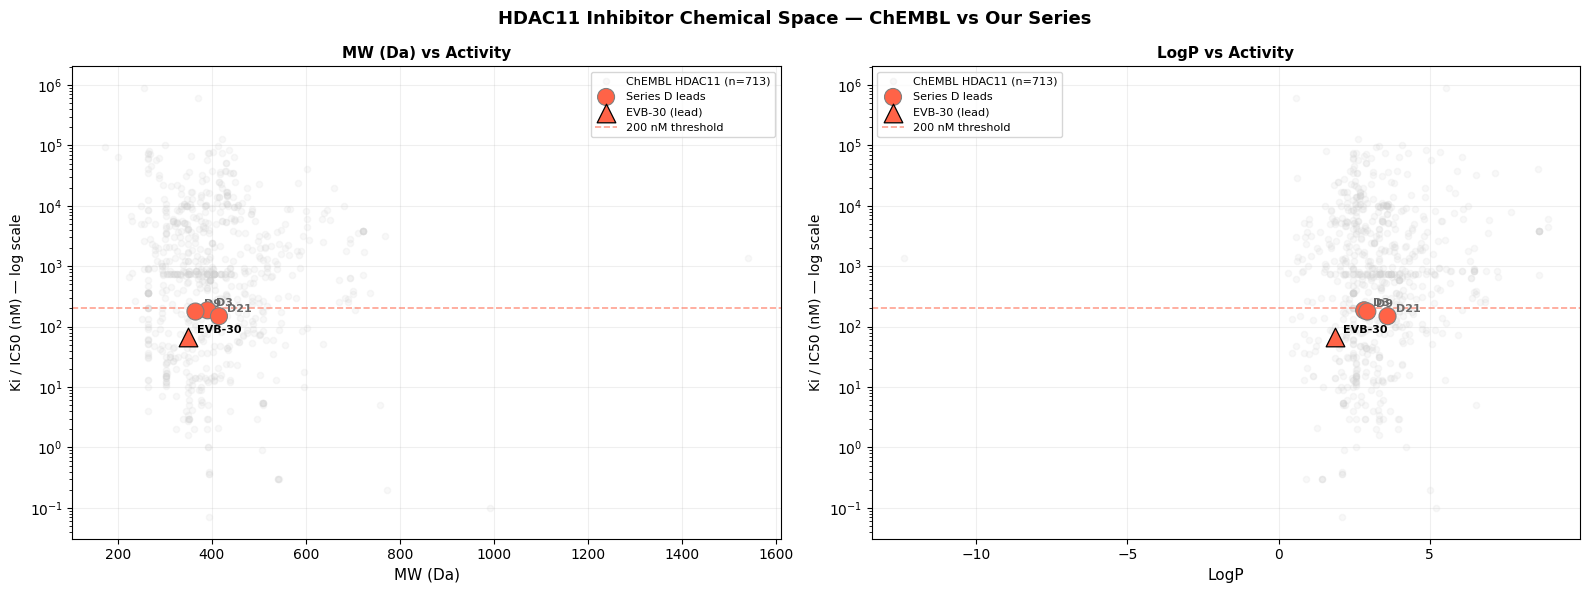

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("HDAC11 Inhibitor Chemical Space — ChEMBL vs Our Series",
             fontsize=13, fontweight="bold")

leads_D   = df_D[df_D["ID"].isin(["D21","D9","D3"])].copy()
leads_evb = df_evb[df_evb["ID"] == "30"].copy()

for ax, x_col, x_label in zip(axes, ["MW","LogP"], ["MW (Da)","LogP"]):

    ax.scatter(df_chembl[x_col], df_chembl["standard_value"],
               alpha=0.15, s=20, color="lightgray", zorder=1,
               label=f"ChEMBL HDAC11 (n={len(df_chembl)})")

    ax.scatter(leads_D[x_col], leads_D["Ki_nM"],
               c=leads_D["Color"], s=150, marker="o",
               edgecolors="gray", linewidths=0.8, zorder=4,
               label="Series D leads")
    for _, row in leads_D.iterrows():
        ax.annotate(row["ID"], (row[x_col], row["Ki_nM"]),
                    fontsize=8, fontweight="bold", color="dimgray",
                    textcoords="offset points", xytext=(6, 3))

    ax.scatter(leads_evb[x_col], leads_evb["Ki_nM"],
               c=leads_evb["Color"], s=180, marker="^",
               edgecolors="black", linewidths=0.9, zorder=5,
               label="EVB-30 (lead)")
    for _, row in leads_evb.iterrows():
        ax.annotate("EVB-30", (row[x_col], row["Ki_nM"]),
                    fontsize=8, fontweight="bold", color="black",
                    textcoords="offset points", xytext=(6, 3))

    ax.set_yscale("log")
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel("Ki / IC50 (nM) — log scale", fontsize=10)
    ax.set_title(f"{x_label} vs Activity", fontsize=11, fontweight="bold")
    ax.axhline(200, color="tomato", linestyle="--",
               linewidth=1.2, alpha=0.6, label="200 nM threshold")
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("chembl_landscape.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(mol):
    try:
        return MurckoScaffold.GetScaffoldForMol(mol)
    except:
        return None

df_chembl["Scaffold"]     = df_chembl["Mol"].apply(get_scaffold)
df_chembl["Scaffold_SMILES"] = df_chembl["Scaffold"].apply(
    lambda m: Chem.MolToSmiles(m) if m else None
)

# Count how many compounds per scaffold
scaffold_counts = df_chembl["Scaffold_SMILES"].value_counts()
print(f"Total unique scaffolds: {len(scaffold_counts)}")
print(f"\nTop 10 most common scaffolds:")
print(scaffold_counts.head(10))

Total unique scaffolds: 302

Top 10 most common scaffolds:
Scaffold_SMILES
c1ccccc1                                                             96
O=c1c2ccccc2n(Cc2ccccc2)c(=O)n1CCc1ccccc1                            22
C(#Cc1cc2ccccc2[nH]1)c1ccccc1                                        16
O=C1N(Cc2ccccc2)CCC12Cc1ccccc1C2                                     14
c1ccc(CNCCc2c[nH]c3ccccc23)cc1                                       14
O=C(CNC(=O)[C@H]1CCC(=O)N1)Nc1ccccc1                                 13
O=C(NCC12C[C@H]3C[C@@H](C1)C[C@@H](C2)C3)c1ccc2c(ccn2Cc2ccccc2)c1    11
c1ccsc1                                                              11
O=C1CCNC(=O)[C@@H](Cc2ccccc2)NC(=O)CNC(=O)CN1                        10
c1ccc2[nH]cnc2c1                                                     10
Name: count, dtype: int64


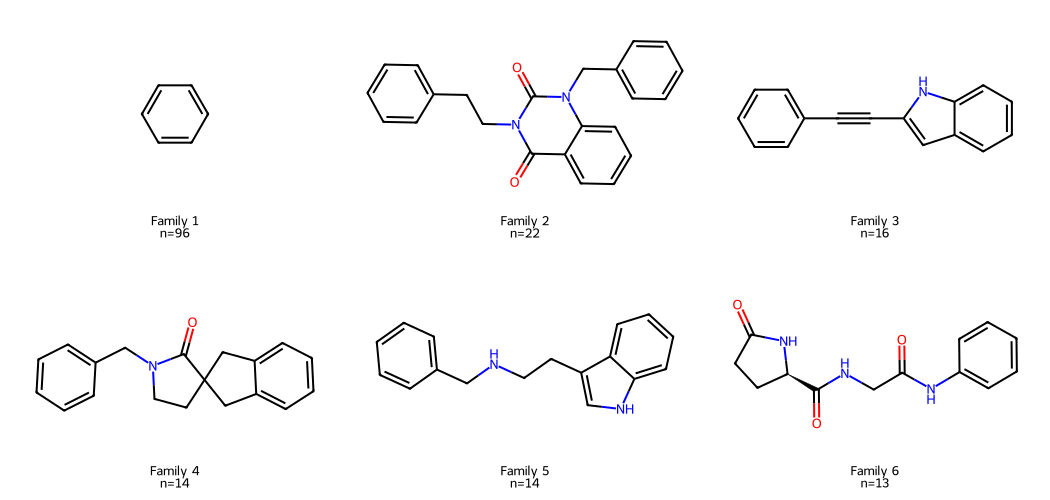

In [41]:
top_scaffolds = scaffold_counts.head(6).index.tolist()

scaffold_mols    = [Chem.MolFromSmiles(s) for s in top_scaffolds]
scaffold_labels  = [f"Family {i+1}\nn={scaffold_counts[s]}"
                    for i, s in enumerate(top_scaffolds)]

img = MolsToGridImage(
    scaffold_mols,
    molsPerRow=3,
    subImgSize=(350, 250),
    legends=scaffold_labels
)
display(img)

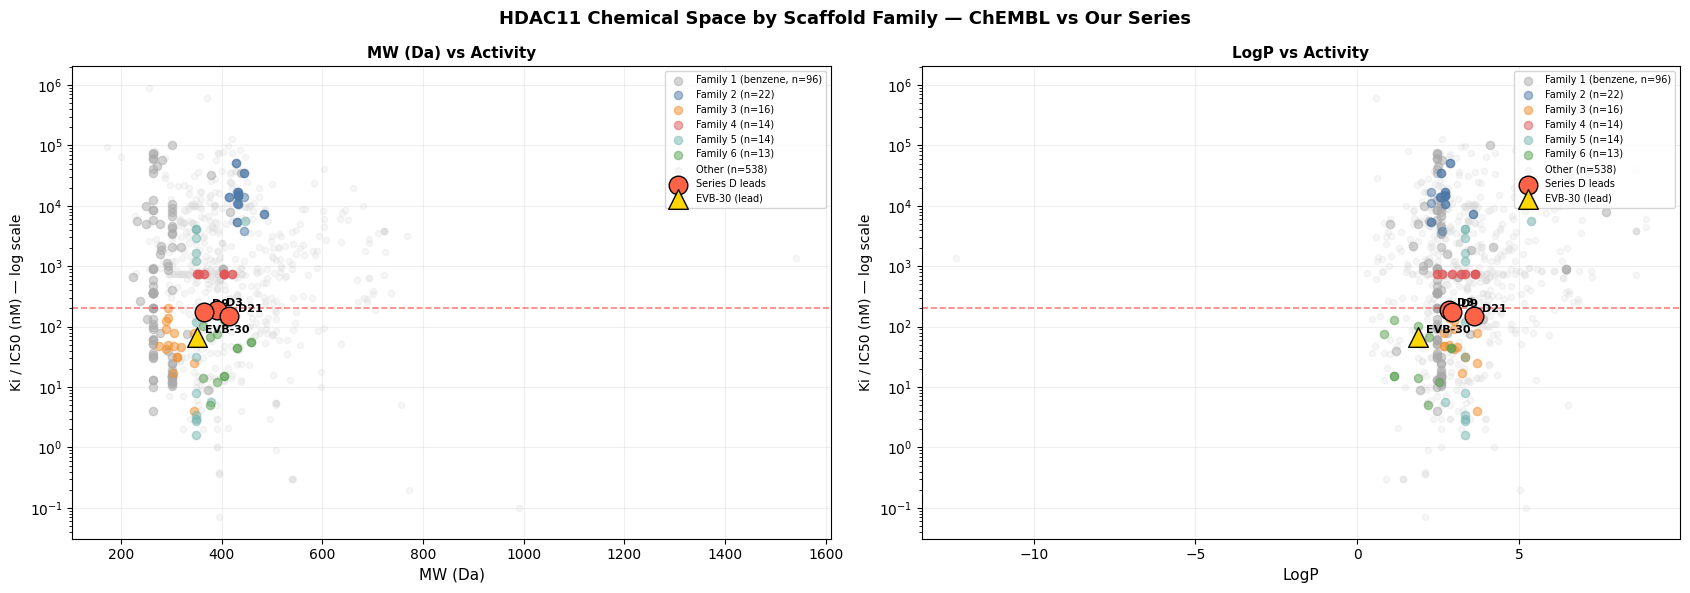

In [42]:
# Assign family label to each ChEMBL compound
top6 = scaffold_counts.head(6).index.tolist()

family_colors = {
    top6[0]: ("Family 1 (benzene, n=96)",   "#aaaaaa"),
    top6[1]: ("Family 2 (n=22)",             "#4e79a7"),
    top6[2]: ("Family 3 (n=16)",             "#f28e2b"),
    top6[3]: ("Family 4 (n=14)",             "#e15759"),
    top6[4]: ("Family 5 (n=14)",             "#76b7b2"),
    top6[5]: ("Family 6 (n=13)",             "#59a14f"),
}

def assign_family(smi):
    if smi in family_colors:
        return family_colors[smi]
    return ("Other", "#dddddd")

df_chembl[["Family","FamilyColor"]] = pd.DataFrame(
    df_chembl["Scaffold_SMILES"].apply(assign_family).tolist(),
    index=df_chembl.index
)

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("HDAC11 Chemical Space by Scaffold Family — ChEMBL vs Our Series",
             fontsize=13, fontweight="bold")

leads_D   = df_D[df_D["ID"].isin(["D21","D9","D3"])].copy()
leads_evb = df_evb[df_evb["ID"] == "30"].copy()

for ax, x_col, x_label in zip(axes, ["MW","LogP"], ["MW (Da)","LogP"]):

    # Plot each family separately for legend
    for smi, (label, color) in family_colors.items():
        subset = df_chembl[df_chembl["Scaffold_SMILES"] == smi]
        ax.scatter(subset[x_col], subset["standard_value"],
                   alpha=0.5, s=35, color=color, zorder=2, label=label)

    # Other scaffolds
    others = df_chembl[df_chembl["Family"] == "Other"]
    ax.scatter(others[x_col], others["standard_value"],
               alpha=0.25, s=20, color="#dddddd", zorder=1, label=f"Other (n={len(others)})")

    # Series D leads
    ax.scatter(leads_D[x_col], leads_D["Ki_nM"],
               c="tomato", s=180, marker="o",
               edgecolors="black", linewidths=1.0, zorder=6, label="Series D leads")
    for _, row in leads_D.iterrows():
        ax.annotate(row["ID"], (row[x_col], row["Ki_nM"]),
                    fontsize=8, fontweight="bold",
                    textcoords="offset points", xytext=(6, 3))

    # EVB lead
    ax.scatter(leads_evb[x_col], leads_evb["Ki_nM"],
               c="gold", s=200, marker="^",
               edgecolors="black", linewidths=1.0, zorder=6, label="EVB-30 (lead)")
    for _, row in leads_evb.iterrows():
        ax.annotate("EVB-30", (row[x_col], row["Ki_nM"]),
                    fontsize=8, fontweight="bold",
                    textcoords="offset points", xytext=(6, 3))

    ax.set_yscale("log")
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel("Ki / IC50 (nM) — log scale", fontsize=10)
    ax.set_title(f"{x_label} vs Activity", fontsize=11, fontweight="bold")
    ax.axhline(200, color="red", linestyle="--", linewidth=1.2, alpha=0.5)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("chembl_landscape_families.png", dpi=150, bbox_inches="tight")
plt.show()